In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from src.data import load_fd001_train, add_rul_labels

df = load_fd001_train("../data/CMAPSS/train_FD001.txt")
df = add_rul_labels(df)

print(df.shape)

feature_cols = (
    ["operational_setting_1", "operational_setting_2", "operational_setting_3"]
    + [f"sensor_measurement_{i}" for i in range(1, 22)]
)
#we want to extract part of the data where the jet engines are working properly so we can train the data on healthy normal data. using RUL = 125 cuz that seems like a good metric 
normal_df = df[df["RUL"] > 125].copy()
scaler = StandardScaler()
scaler.fit(normal_df[feature_cols])

normal_scaled = scaler.transform(normal_df[feature_cols])
all_scaled = scaler.transform(df[feature_cols])
normal_df_scaled = normal_df[["unit_number", "time_in_cycles", "RUL"]].copy()
normal_df_scaled[feature_cols] = normal_scaled

all_df_scaled = df[["unit_number", "time_in_cycles", "RUL"]].copy()
all_df_scaled[feature_cols] = all_scaled


#constructing the forward pass 


class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=24, latent_dim=32):
        super().__init__()
        self.encoder = nn.LSTM(input_size=24, hidden_size=32, num_layers=1, batch_first=True) #cuz input shape is (batch, timesteps, features) 
        self.decoder = nn.LSTM(input_size = 32, hidden_size = 24, num_layers=1, batch_first=True)

    def forward(self, x):
        #encode it first
        _, (hidden, _) = self.encoder(x)
        repeated = hidden.squeeze(0).unsqueeze(1).repeat(1, x.size(1), 1) 
        #now decode to get reconstruction and then compute reconstruction error
        reconstruction, _ = self.decoder(repeated)
        
        return reconstruction

#we will use MSE to compute reconstruction error later
    
def create_windows(dataframe, feature_cols, window_size=30):
    X, ruls = [], []
    for engine_id, group in dataframe.groupby("unit_number"):
        group = group.sort_values("time_in_cycles")
        data  = group[feature_cols].values
        rul   = group["RUL"].values
        for i in range(len(data) - window_size + 1):
            X.append(data[i : i + window_size])
            ruls.append(rul[i + window_size - 1])
    return np.array(X, dtype=np.float32), np.array(ruls, dtype=np.float32)
#training. i chose window size as 30 
window_size = 30 
X_normal, _ = create_windows(normal_df_scaled, feature_cols, window_size) # we are creating an array here that contains NORMAL data thats scaled of 30 window size
X_tensor = torch.tensor(X_normal) #since pytorch doesnt support numpy arrays, we are convering the data into tensors 
dataset = TensorDataset(X_tensor, X_tensor) #this just means that the x_tensor is the input and its also supposed to be the output in this case 
loader = DataLoader(dataset, batch_size=64, shuffle=True) 
#batch_size = 64. each batch has 64 windows, and each window is 30 time steps. 

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = LSTMAutoencoder(n_features=24, latent_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) #optimizer that adjusts the weights after each epoch 
criterion = nn.MSELoss() #evaluation metric we are using 

EPOCHS = 30 
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0 
    for x_batch, y_batch in loader: 
        x_batch = x_batch.to(device) 
        reconstruction = model(x_batch) 
        loss = criterion(reconstruction, x_batch) 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(loader)
    if (epoch + 1) % 5 == 0: 
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {avg_loss:.6f}")




(20631, 27)
Epoch 5/30 — Loss: 0.406115
Epoch 10/30 — Loss: 0.400199
Epoch 15/30 — Loss: 0.396946
Epoch 20/30 — Loss: 0.395112
Epoch 25/30 — Loss: 0.393515
Epoch 30/30 — Loss: 0.392383


In [6]:
#evaluation
model.eval()

X_all_tensor = torch.tensor(X_all).to(device)

with torch.no_grad():
    reconstructions = model(X_all_tensor)
    scores = torch.mean((X_all_tensor - reconstructions) ** 2, dim=(1, 2))
    scores = scores.cpu().numpy()

# Set threshold at 95th percentile of normal reconstruction errors
X_normal_tensor = torch.tensor(X_normal).to(device)
with torch.no_grad():
    normal_recon  = model(X_normal_tensor)
    normal_scores = torch.mean((X_normal_tensor - normal_recon) ** 2, dim=(1, 2))
    normal_scores = normal_scores.cpu().numpy()

threshold = np.percentile(normal_scores, 95)
print(f"Threshold: {threshold:.6f}")
print(f"Max anomaly score: {scores.max():.6f}")
print(f"Min anomaly score: {scores.min():.6f}")

Threshold: 0.504309
Max anomaly score: 17.298845
Min anomaly score: 0.278572


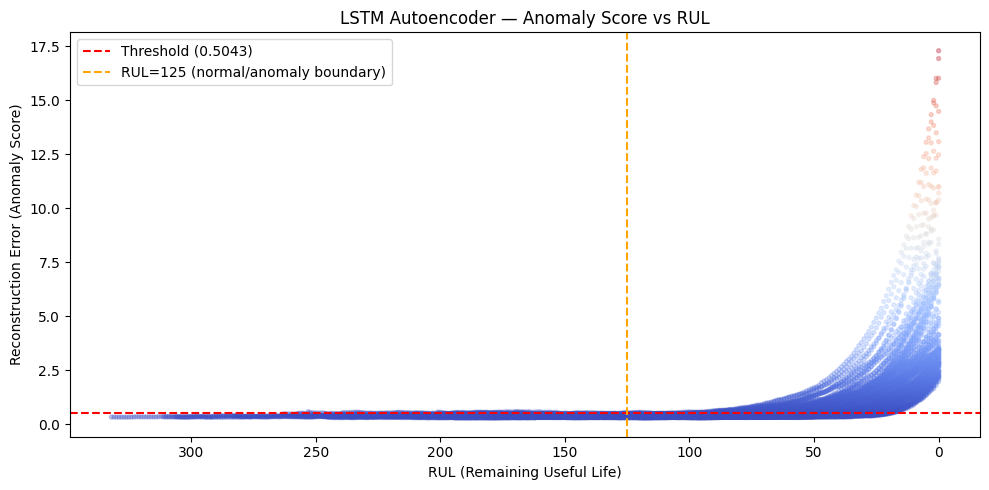

In [7]:
#visualization
plt.figure(figsize=(10, 5))
plt.scatter(ruls_all, scores, alpha=0.3, s=8, c=scores, cmap="coolwarm")
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold:.4f})')
plt.axvline(x=125, color='orange', linestyle='--', linewidth=1.5, label='RUL=125 (normal/anomaly boundary)')
plt.xlabel("RUL (Remaining Useful Life)")
plt.ylabel("Reconstruction Error (Anomaly Score)")
plt.title("LSTM Autoencoder — Anomaly Score vs RUL")
plt.legend()
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("../results/lstm_ae_anomaly_scores.png", dpi=150)
plt.show()